# All-speaker acoustic geometry baseline
Separate lab project: F0 median, F1, F2, F3, duration. Four views: phoneme pooled, phoneme within speaker, speaker pooled, speaker within phoneme. This is descriptive geometry, not held-out prediction. Conditional scores are averaged after subgroup evaluation. See config.py for sampling and clustering settings.

In [1]:
from pathlib import Path
import sys, runpy, subprocess, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().parents[1] if Path.cwd().name=='vowel_geometry' else Path.cwd()
assert (ROOT/'metadata_vowels_acoustics.csv').exists()
sys.path.insert(0,str(ROOT))
CONFIG_PATH = ROOT/'lab_projects/vowel_geometry/config.py'
display(runpy.run_path(str(CONFIG_PATH))['CONFIG'])
print('Interpreter:',sys.executable)
# Set None for a fresh run.
RESUME_RUN = ROOT/'lab_projects/vowel_geometry/results/20260929_173507'

{'csv_path': 'metadata_vowels_acoustics.csv',
 'features': ['f0_median_hz', 'f1_hz', 'f2_hz', 'f3_hz', 'duration_s'],
 'seeds': [42, 43, 44],
 'fit_sample_seed': 2026,
 'fit_sample_max': 50000,
 'query_large': 1500,
 'query_small': 300,
 'large_group_threshold': 10000,
 'distance_chunk': 32,
 'kmeans_n_init': 10,
 'kmeans_max_iter': 300,
 'kmeans_tol': 0.0001,
 'workers': 2,
 'threads': 1,
 'output_dir': 'lab_projects/vowel_geometry/results'}

Interpreter: C:\Users\46021\.conda\envs\lffl\python.exe


In [2]:
command = [sys.executable,str(ROOT/'lab_projects/vowel_geometry/analyze.py'),'--config',str(CONFIG_PATH)]
if RESUME_RUN is not None:
    command += ['--resume',str(RESUME_RUN)]
p = subprocess.Popen(command,cwd=ROOT,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
run_dir = RESUME_RUN
for line in p.stdout:
    print(line,end='')
    if line.startswith('RUN DIRECTORY: '):
        run_dir = Path(line.strip().split('RUN DIRECTORY: ',1)[1])
assert p.wait()==0
display(json.loads((run_dir/'complete.json').read_text()))

COMPLETE: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results\20260929_173507


{'groups': 105, 'clustering_fits': 315, 'n_tokens': 447265}

REPORT: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results\20260929_173507\REPORT.html


,view,weighting,metric,mean,repeat_sd,between_group_sd,minimum_group_mean,maximum_group_mean,n_groups,n_tokens
0,phoneme_pooled,macro,truth_silhouette,0.030438,0.002838,NaN,0.030438,0.030438,1,447265
10,phoneme_pooled,macro,ari,0.126135,0.000054,NaN,0.126135,0.126135,1,447265
11,phoneme_pooled,macro,nmi,0.164941,0.000029,NaN,0.164941,0.164941,1,447265
12,phoneme_pooled,macro,ami,0.164932,0.000029,NaN,0.164932,0.164932,1,447265
32,phoneme_given_speaker,macro,truth_silhouette,0.089455,0.001841,0.046652,-0.023238,0.192978,98,447265
42,phoneme_given_speaker,macro,ari,0.285419,0.001517,0.116497,0.092789,0.560768,98,447265
43,phoneme_given_speaker,macro,nmi,0.330370,0.000780,0.104132,0.126699,0.557758,98,447265
44,phoneme_given_speaker,macro,ami,0.329605,0.000780,0.104252,0.125721,0.557264,98,447265
64,speaker_pooled,macro,truth_silhouette,-0.131667,0.003167,NaN,-0.131667,-0.131667,1,447265
74,speaker_pooled,macro,ari,0.012138,0.000087,NaN,0.012138,0.012138,1,447265


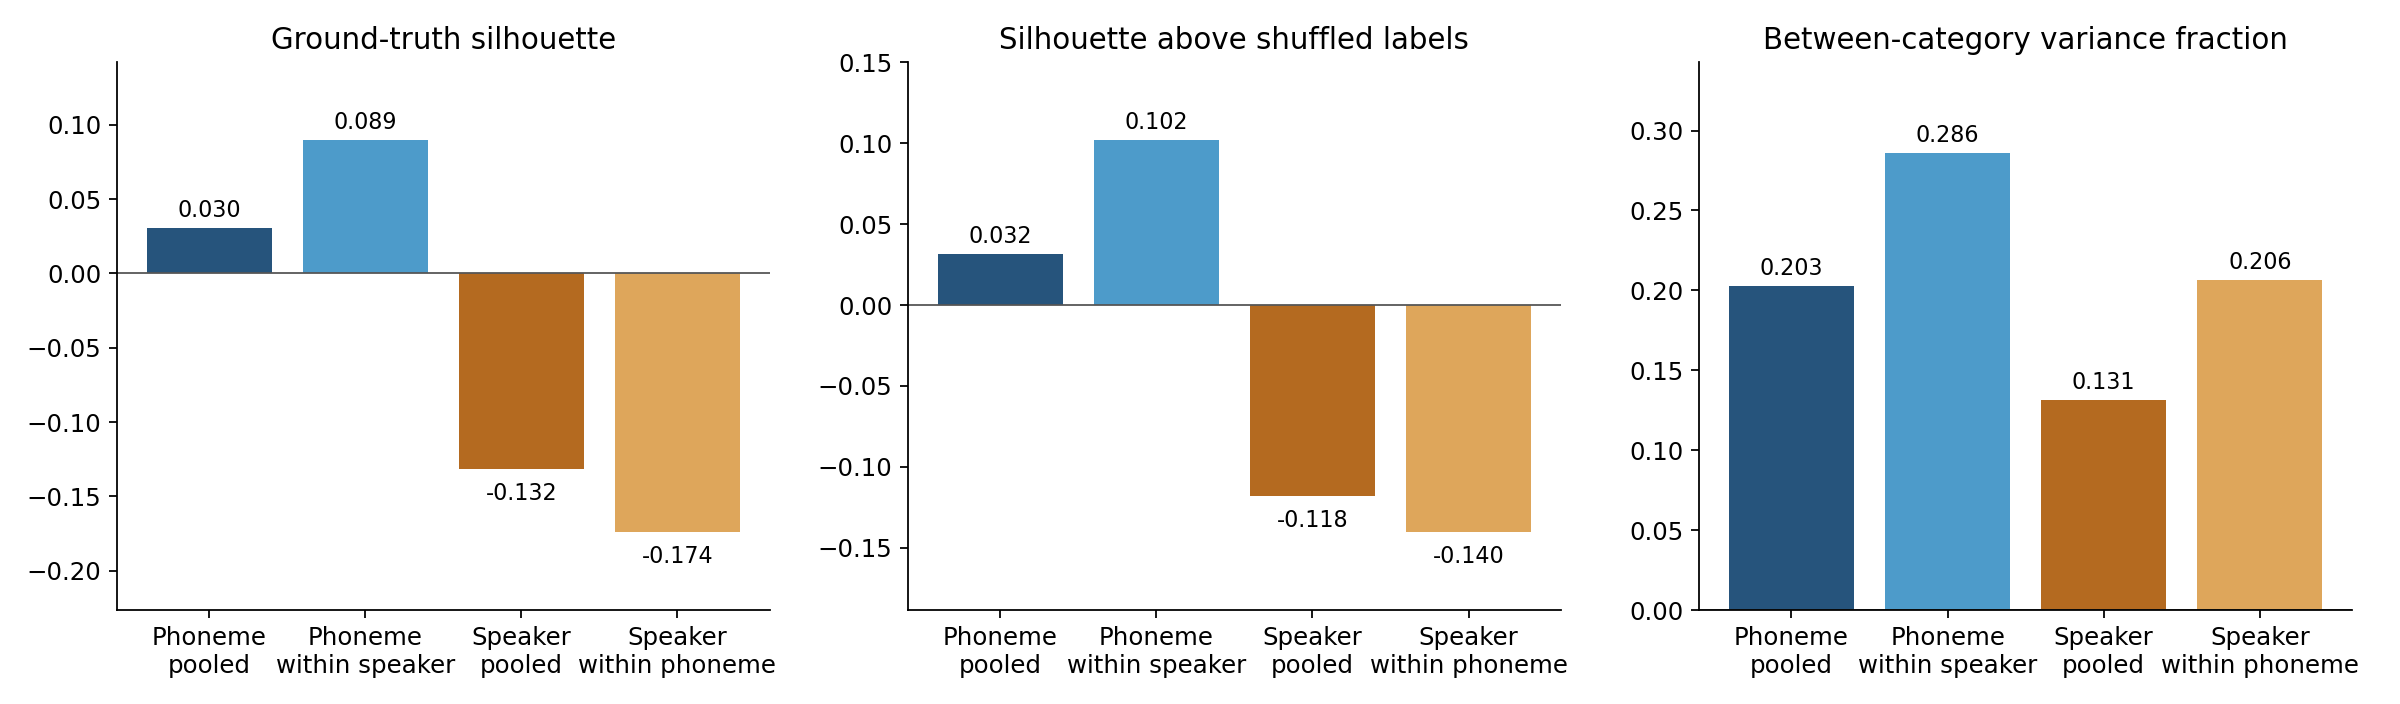

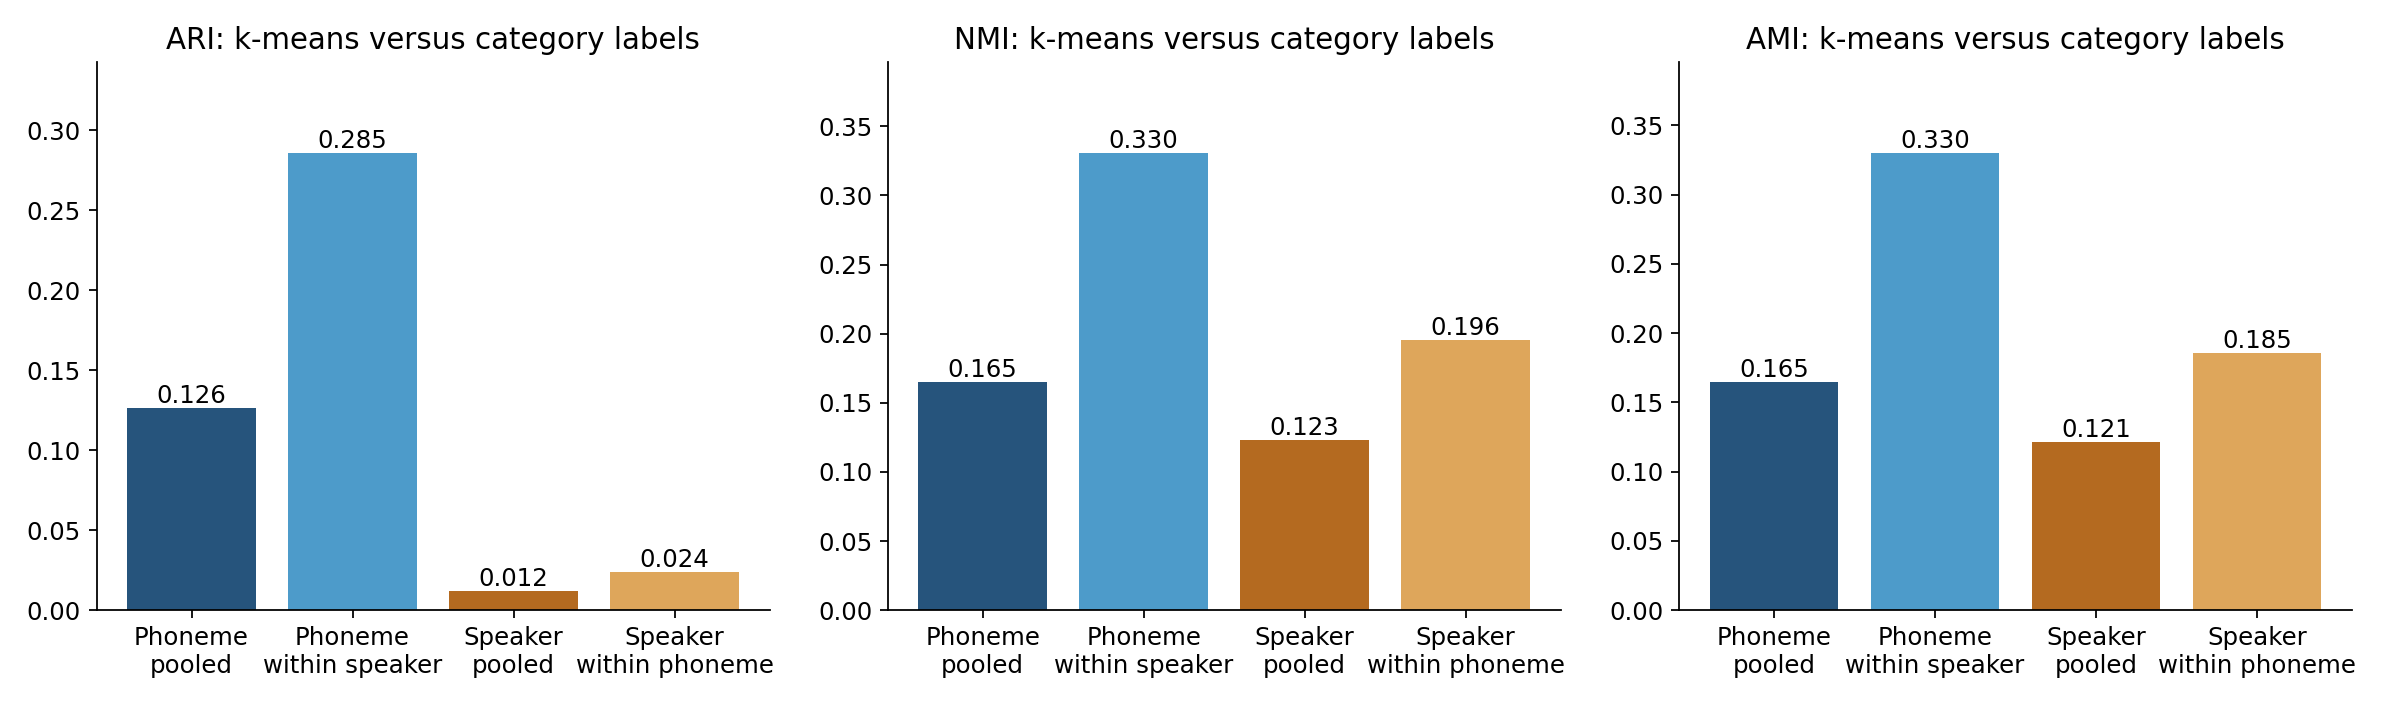

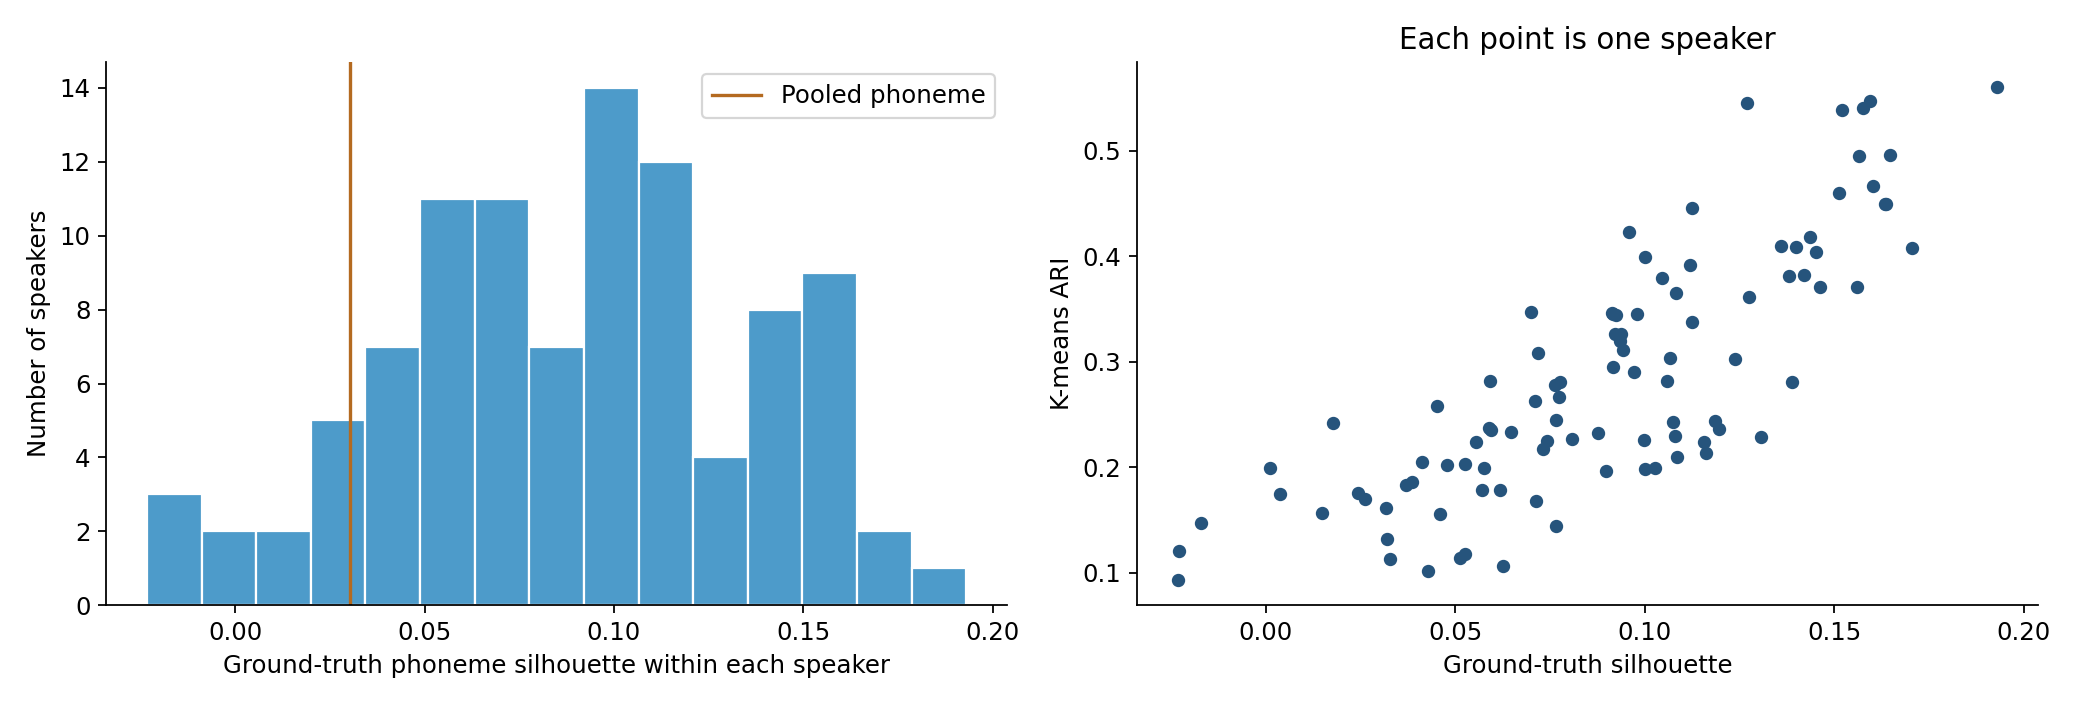

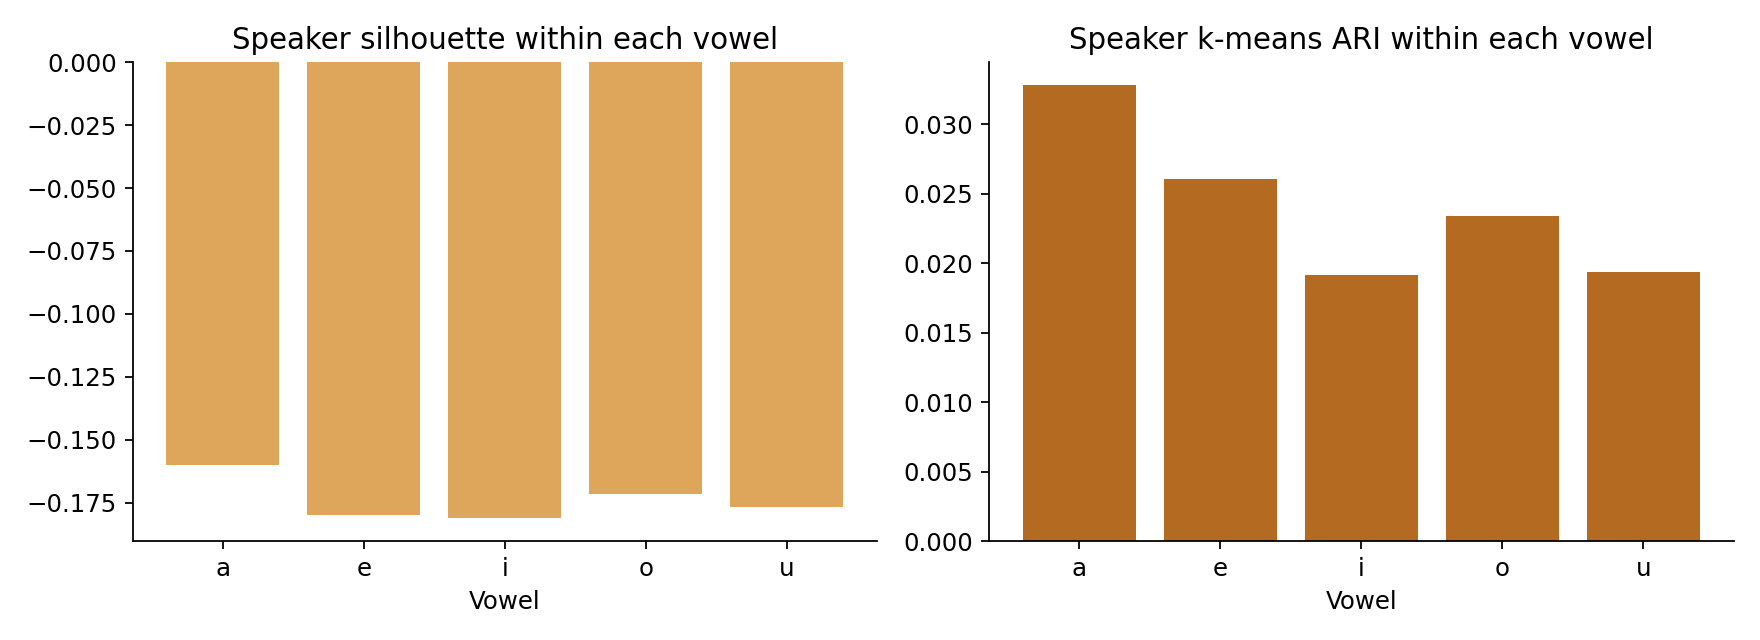

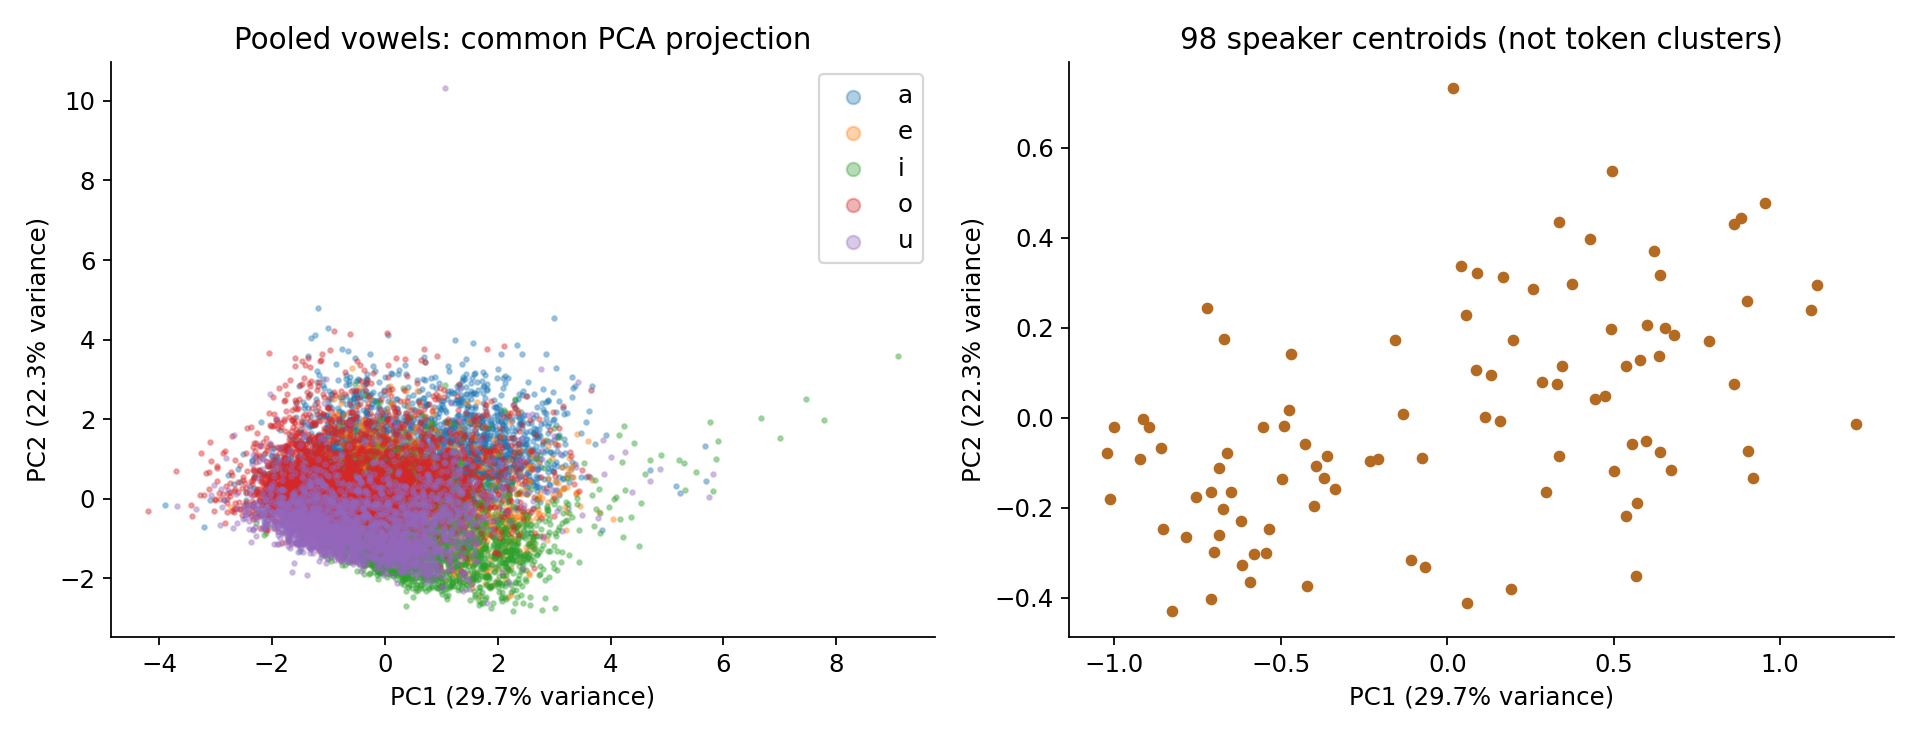

Readable report: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\lab_projects\vowel_geometry\results\20260929_173507\REPORT.html


In [3]:
from lab_projects.vowel_geometry.report import make_report
report = make_report(run_dir)
summary = pd.read_csv(run_dir/'summary.csv')
display(summary[(summary.weighting=='macro') & summary.metric.isin(['truth_silhouette','ari','nmi','ami'])])
for name in ('ground_truth','cluster_agreement','speaker_variation','phoneme_variation','pca'):
    display(Image(filename=str(run_dir/'figures'/f'{name}.png')))
print('Readable report:',report)

In [4]:
import numpy as np
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
metrics = pd.read_csv(run_dir/'metrics.csv')
assert len(metrics)==315 and metrics.groupby(['view','group']).seed.nunique().eq(3).all()
assert metrics.groupby('view').n.sum().eq(447265*3).all()
assert not metrics.fit_hit_max_iter.any()
for view,group in [('phoneme_pooled','all'),('speaker_given_phoneme','a')]:
    a = pd.read_csv(run_dir/'groups'/f'{view}__{group}'/'assignments_seed_42.csv')
    row = metrics[(metrics.view==view)&(metrics.group==group)&(metrics.seed==42)].iloc[0]
    np.testing.assert_allclose(adjusted_rand_score(a.truth,a.cluster),row.ari)
    np.testing.assert_allclose(normalized_mutual_info_score(a.truth,a.cluster),row.nmi)
print('All groups/seeds and two saved-assignment metric reproductions verified.')

All groups/seeds and two saved-assignment metric reproductions verified.
